# 5: Latent Variable Models (Logistic Regression)
Kaitlin Luu

### Q1

1. Linear models can only produce accurate predictions when the data is normally distributed. General linear models, latent variable models, and activation functions allow us to make predictions with data that are complex. These models can identify underlying patterns and bypass aspects that are irrelevant to enhance accuracy and help us better understand the data. 

2. Binary and categorical cross entropy are effective loss functions for logistic regression because they are based on MLE, which allows the model to maximize the probability of the observed data. It does this by creating a process the finds the set of model parameters that result in the smallest possible error (loss). This creates a penalty that prevents the model from misclassifying, which ensures that the model produces consistent gradients when being trained.

3. This is true because logistic regression creates a decision boundary that is a linear combination of features from the input. Thus, the workings of the model are linear, even though the output goes through a non-linear activation function. 

4. This is false. Logistic regression can be used for classification because it is designed to predict the probability of an outcome for a categorical variable. It uses the sigmoid function to map the probability of an outcome occurring, and then uses a threshold to classify it as 0 or 1.

5. No, the coefficient in a logistic regression does not represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable. This is only true in linear regression. In logistic regression, however, it represents the change in the log-odds for a 1 unit change in x. Log-odds are the odds of an event occurring (ratio of success to failure), with the natural log applied that ratio. 

6. This is false because logistic regression is fundamentally a linear model. It is based on a linear combination of the input features to predict the odds of an event occurring. This makes feature engineering an essential aspect of training a model because it allows the model to understand non-linear relationships as well. 

7. This is false. Logistic regression is not necessarily an improvement over the usual linear model because the two models are simply used in different scenarios. When you have a continuous target variable, linear regression (OLS) is used since it minimizes the distance between the predicted values and the actual data. On the other hand, when you have a categorical target variable, logistic regression is used since it finds the probability of a categorical outcome. Therefore, you should not always use logistic regression since it depends on the data type of the event being predicted. 

### Q2

In [1]:
# 1

import pandas as pd
import numpy as np

df = pd.read_csv('data/data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
COLS = ['Debtor',
        'Tuition fees up to date',
        'Scholarship holder',
        'Age at enrollment',
        'Curricular units 1st sem (approved)',
        'Target'
]

df = df[COLS]

# missing values check
print(df.isnull().sum())

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


There are no missing values, so there is no need for imputation or dropping rows.

In [3]:
# binary target: dropout = 1, graduate/enrolled = 0

df['dropout'] = (df['Target'] == 'Dropout').astype(int)

binary = ['Debtor',
          'Tuition fees up to date',
          'Scholarship holder', 
          'Age at enrollment'
]

X_bin = df[binary]
y_bin = df['dropout']

In [4]:
# 2

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_bin, y_bin)

coef_df = pd.DataFrame(
    {'Variable': X_bin.columns, 'Coefficient': log_reg.coef_[0]}
).sort_values('Coefficient')

print('Logistic Regression Coefficients:', coef_df)

Logistic Regression Coefficients:                   Variable  Coefficient
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925
0                   Debtor     0.530625


Age at enrollment and Debtor have positive coefficients, indicating that as these variables increase, dropout probability increases. On the other hand, Tuition fees up to date and Scholarship holder predict a lower dropout probability, as shown by the negative coefficients. Being up to date on tuition seems to be the strongest predictor of reducing dropout. 

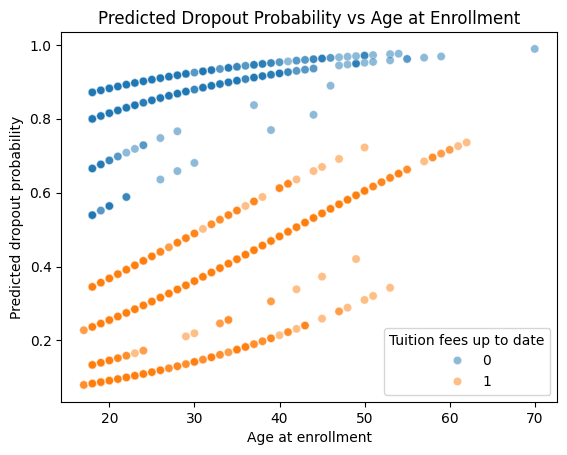

In [5]:
# 3

import seaborn as sns
import matplotlib.pyplot as plt

df['p_dropout_log'] = log_reg.predict_proba(X_bin)[:, 1]
sns.scatterplot(
    data=df, x='Age at enrollment',
    y='p_dropout_log',
    hue='Tuition fees up to date',
    alpha=0.5)

plt.title('Predicted Dropout Probability vs Age at Enrollment')
plt.ylabel('Predicted dropout probability')
plt.legend(title='Tuition fees up to date')
plt.show()

In [6]:
p_up   = df.loc[df["Tuition fees up to date"] == 1, "p_dropout_log"].mean()
p_down = df.loc[df["Tuition fees up to date"] == 0, "p_dropout_log"].mean()
avg_reduction = p_down - p_up
print('Avg reduction in risk when up to date:', avg_reduction)

Avg reduction in risk when up to date: 0.6125849339838294


The reduction in dropout probability is more dramatic as for younger and middle-aged students. On average, being up to date on tuition reduced dropout probability by about 61.3%. 

In [7]:
# 4
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred_log = log_reg.predict(X_bin)
cm_log = confusion_matrix(y_bin, y_pred_log)
acc_log = accuracy_score(y_bin, y_pred_log)

print('Logistic regression accuracy:', acc_log)
print('Confusion matrix:\n', cm_log)

Logistic regression accuracy: 0.7619801084990958
Confusion matrix:
 [[2841  162]
 [ 891  530]]


The accuracy of the logistic regression is about 76.2%.

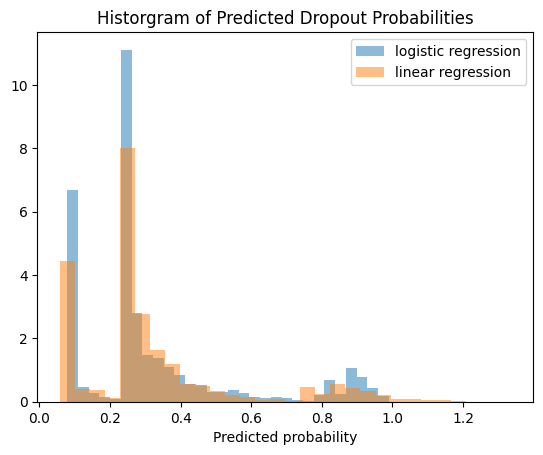

In [8]:
# 5

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_bin, y_bin)

df['p_dropout_lin'] = lin_reg.predict(X_bin)

plt.hist(df['p_dropout_log'], bins=30, alpha=0.5, label='logistic regression', density=True)
plt.hist(df['p_dropout_lin'], bins=30, alpha=0.5, label='linear regression', density=True)
plt.xlabel('Predicted probability')
plt.title('Historgram of Predicted Dropout Probabilities')
plt.legend()
plt.show()

6. 
The students who are the most at risk of dropping out are those who are older, in debt, do not have a scholarship, and are not up to date on tuition payments. Resources such as accessible financial counseling, targeting scholarships, flexible payment plans, and increased advising could help at-risk students stay enrolled. 

In [9]:
# 7

multi = [
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)",
]
X_multi = df[multi]
y_multi = df["Target"]

multi_log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)
multi_log_reg.fit(X_multi, y_multi)

y_pred_multi = multi_log_reg.predict(X_multi)
cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=multi_log_reg.classes_)
print('Multinomial logistic regression confusion matrix:\n', cm_multi)

Multinomial logistic regression confusion matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


Based on the confusion matrix, the model correctly classified 1054 dropouts and 2063 graduates, and the 794 enrolled students were misclassified. 

In [10]:
unique_pred_hard = np.unique(y_pred_multi)
y_prob_multi = multi_log_reg.predict_proba(X_multi)
soft_highest = multi_log_reg.classes_[np.unique(np.argmax(y_prob_multi, axis=1))]

print('Hard predictions (unique):', unique_pred_hard)
print('Classes with the highest soft probability:', soft_highest)

Hard predictions (unique): ['Dropout' 'Graduate']
Classes with the highest soft probability: ['Dropout' 'Graduate']


The hard classification model only classifies students as Dropout or Graduate. This means that it misclassifies students who are currently enrolled.

On the other hand, the soft classification model does classify students as Enrolled. However, among the three classes, the probability for Enrolled is never the highest. This indicates that our chosen variables (debt, tuition payment, and courses passed) are good predictors of whether a person drops out or graduates, but is not necessarily good for predicting whether a student is simply enrolled. 

### Q3

In [11]:
# 1

df = pd.read_csv('data/cirrhosis.csv')
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [12]:
COLS = ['Status', 'Drug', 'Bilirubin', 'Edema', 'Stage']
df = df[COLS]
df.isna().sum()

Status         0
Drug         106
Bilirubin      0
Edema          0
Stage          6
dtype: int64

In [13]:
# drop missing
df = df.dropna(subset=['Drug'])

The Drug feature has 106 missing values, so I dropped those rows with .dropna() since we will be looking at the drug's effect. 

In [14]:
# 2

import statsmodels.api as sm

# make status and drug binary variables
df['Status_Binary'] = df['Status'].map({'C': 1, 'CL': 1, 'D': 0}).astype(float)
df['Drug_Binary'] = df['Drug'].map({'D-penicillamine': 1, 'Placebo': 0}).astype(float)

edema_dummies = pd.get_dummies(df['Edema'], prefix='Edema').astype(float)
df_reg = pd.concat([df, edema_dummies], axis=1)

feature_cols = ['Drug_Binary', 'Bilirubin', 'Edema_S', 'Edema_Y']
X = df_reg[feature_cols].astype(float)
X_sm = sm.add_constant(X)
y = df_reg['Status_Binary']

In [15]:
log = sm.Logit(y, X_sm).fit(disp=0)
print('Logistic regression summary (Survival):\n', log.summary())

Logistic regression summary (Survival):
                            Logit Regression Results                           
Dep. Variable:          Status_Binary   No. Observations:                  312
Model:                          Logit   Df Residuals:                      307
Method:                           MLE   Df Model:                            4
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2119
Time:                        14:19:34   Log-Likelihood:                -165.55
converged:                       True   LL-Null:                       -210.06
Covariance Type:            nonrobust   LLR p-value:                 2.117e-18
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.6614      0.254      6.549      0.000       1.164       2.159
Drug_Binary    -0.2527      0.269     -0.938      0.348      -0.781       0.275
Bilirub

The drug has a coefficient of -0.2527 and a p-value of 0.348. The negative coefficient indicates that the drug does not improve survival probability and instead may actually mean the opposite. 

The bilirubin effect has a coefficient of -0.3504, which indicates that higher bilirubin levels predict a lower survival rate. Both edema_S and edema_Y tend to lower survival rate as well. In particular, edema_Y has a very strong negative effect on survival, with a coefficient of -2.859.

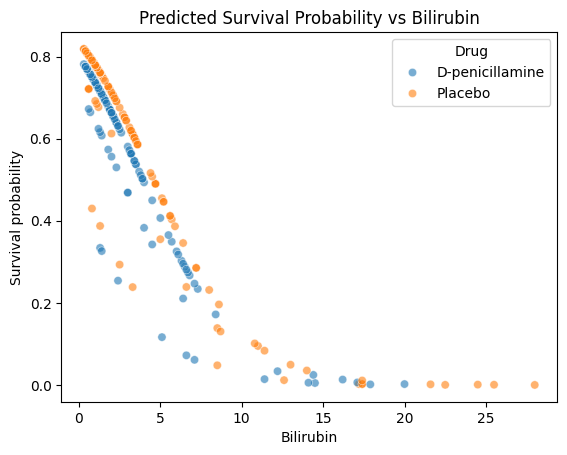

In [16]:
# 3

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X, y)
df_reg['pred_proba_logit'] = log_reg.predict_proba(X)[:, 1]

sns.scatterplot(data=df_reg, x='Bilirubin', y='pred_proba_logit', hue='Drug', alpha=0.6)
plt.title('Predicted Survival Probability vs Bilirubin')
plt.ylabel('Survival probability')
plt.show()

In [17]:
avg_drug = df_reg[df_reg['Drug_Binary'] == 1]['pred_proba_logit'].mean()
avg_placebo = df_reg[df_reg['Drug_Binary'] == 0]['pred_proba_logit'].mean()

print('Drug survival rate (avg):', avg_drug)
print('Placebo survival rate (avg):', avg_placebo)

Drug survival rate (avg): 0.5899901364370072
Placebo survival rate (avg): 0.6089710160436076


According to the scatter plot, lower Bilirubin values seem to increase patient survival rate for the drug.

On average, patients who took the drug had a survival probability of 59%, while patients who took the placebo had a survival probability of 60.9%. Therefore, the drug decreased survival rate by 1.9%. 

In [18]:
# 4

df_reg['pred_label_logit'] = log_reg.predict(X)
cm_log = confusion_matrix(y, df_reg['pred_label_logit'])
acc_log = accuracy_score(y, df_reg['pred_label_logit'])

print('Accuracy:', acc_log)
print('Confusion matrix:\n', cm_log)

Accuracy: 0.7371794871794872
Confusion matrix:
 [[ 59  66]
 [ 16 171]]


The accuracy for the model is 73.7%.

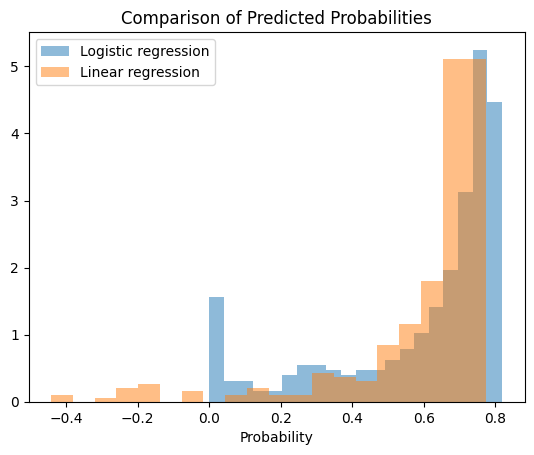

In [19]:
# 5

lin_reg = LinearRegression()
lin_reg.fit(X, y)
df_reg['pred_proba_lin'] = lin_reg.predict(X)
plt.hist(df_reg['pred_proba_logit'], bins=20, alpha=0.5, label='Logistic regression', density=True)
plt.hist(df_reg['pred_proba_lin'], bins=20, alpha=0.5, label='Linear regression', density=True)
plt.title('Comparison of Predicted Probabilities')
plt.xlabel('Probability')
plt.legend()
plt.show()

The histogram shows that the logistic regression predicts normal probabilities between 0 and 1, while the linear model predicts negative probabilities, which is not possible. This indicates that the logistic regression model is the best predictor in this case. 

In [20]:
# 6

df_stage = df_reg.dropna(subset=['Stage']).copy()
X_stage = df_stage[['Bilirubin', 'Edema_S', 'Edema_Y']].astype(float)
y_stage = df_stage['Stage'].astype(int)

stage_log = LogisticRegression(max_iter=1000)
stage_log.fit(X_stage, y_stage)
df_stage['pred_stage'] = stage_log.predict(X_stage)
stage_probs = stage_log.predict_proba(X_stage)

cm_stage = confusion_matrix(y_stage, df_stage['pred_stage'])
df_stage_probs = pd.DataFrame(stage_probs, columns=stage_log.classes_)

print('Confusion matrix (stage):\n', cm_stage)
print('\nStages predicted:', np.unique(df_stage['pred_stage']))
print('\nMin/max  probability for each stage:\n', df_stage_probs.agg(['min', 'max']))

Confusion matrix (stage):
 [[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]

Stages predicted: [3 4]

Min/max  probability for each stage:
                 1         2         3         4
min  2.982598e-09  0.012899  0.104528  0.255662
max  1.100461e-01  0.255032  0.428496  0.882573


For the hard classification, the model only predicted Stage 3 and 4 and did not predict Stage 1 or 2 for any patient. 

However, for the predicted probabilities, every class was predicted. This being said, Stage 1 and 2 were never among the highest probabilities. This shows that the model struggles to distinguish the early stages (1 and 2) from later stages (3 and 4), likely because high levels of Bilirubin and Edema are indicators of the disease in the later stages.

### Q4

![question 4](hw5q4.jpg)